In [61]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import numpy as np
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 150)

In [ ]:
os.chdir("../") # set cwd to root dir

In [7]:
id_column = "sub"

In [8]:
participant_overview_df = pd.read_csv("data/DUO-GAIT/raw/subject_info.csv")

In [9]:
participant_overview_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sub                      16 non-null     object 
 1   sex                      16 non-null     object 
 2   age                      16 non-null     int64  
 3   height(cm)               16 non-null     float64
 4   weight(kg)               16 non-null     float64
 5   leg_length(cm)           16 non-null     float64
 6   activity_level           16 non-null     int64  
 7   dual_task_visit          16 non-null     int64  
 8   dt_start_num1            16 non-null     int64  
 9   dt_start_num2            16 non-null     int64  
 10  st_lac_baseline1         16 non-null     float64
 11  st_lac_baseline2         16 non-null     float64
 12  st_lac_fatigue           16 non-null     float64
 13  st_time_to_fatigue(min)  16 non-null     float64
 14  st_borg_scale            16 

In [12]:
participant_overview_df

,sub,sex,age,height(cm),weight(kg),leg_length(cm),activity_level,dual_task_visit,dt_start_num1,dt_start_num2,st_lac_baseline1,st_lac_baseline2,st_lac_fatigue,st_time_to_fatigue(min),st_borg_scale,st_HR_baseline,st_HR_fatigue,dt_lac_baseline1,dt_lac_baseline2,dt_lac_fatigue,dt_time_to_fatigue(min),dt_borg_scale,dt_HR_baseline,dt_HR_fatigue
0,sub_01,M,24,173.0,70.0,82.5,3,2,5308,7942,0.8,0.8,4.8,22.0,18.0,62,185,0.7,0.8,3.2,18.0,18.0,63.0,178.0
1,sub_02,M,29,181.0,73.5,88.0,2,2,3824,8895,0.6,0.7,3.4,24.0,18.0,60,156,0.6,0.5,3.0,30.0,18.0,65.0,167.0
2,sub_03,M,27,190.0,103.0,93.5,3,2,6267,8818,1.5,1.5,2.8,11.0,17.5,73,157,1.0,1.1,2.5,9.0,18.0,NaN,NaN
3,sub_05,F,31,169.0,63.5,81.5,2,2,5052,5590,0.7,0.6,5.5,12.0,17.5,72,168,1.1,0.8,4.3,15.0,17.0,69.0,159.0
4,sub_06,M,35,170.0,80.0,85.0,2,1,7362,8004,1.0,1.1,5.1,15.0,18.0,70,171,0.9,0.8,8.0,9.5,17.0,71.0,166.0
5,sub_07,F,28,157.5,60.0,78.0,2,1,8776,8246,1.0,1.3,3.4,16.5,18.0,70,186,0.7,0.8,4.3,39.0,18.0,78.0,186.0
6,sub_08,F,26,168.5,70.0,82.0,3,2,7930,4675,0.6,0.6,7.0,6.5,18.5,91,182,0.6,0.5,4.2,7.0,18.0,83.0,180.0
7,sub_09,M,27,185.0,79.0,86.0,1,2,4203,7526,0.9,0.8,8.7,12.5,18.0,73,186,0.9,0.7,9.1,8.5,18.0,84.0,188.0
8,sub_10,F,26,169.0,72.0,85.0,2,1,5540,6907,1.6,1.5,3.3,12.0,16.0,77,173,0.8,0.6,5.2,10.5,16.0,78.0,186.0
9,sub_11,M,29,184.0,81.0,86.0,3,2,3809,6626,1.1,1.0,1.7,30.0,16.0,71,152,1.3,1.1,3.2,11.5,16.0,79.0,175.0


<Axes: xlabel='sex', ylabel='count'>

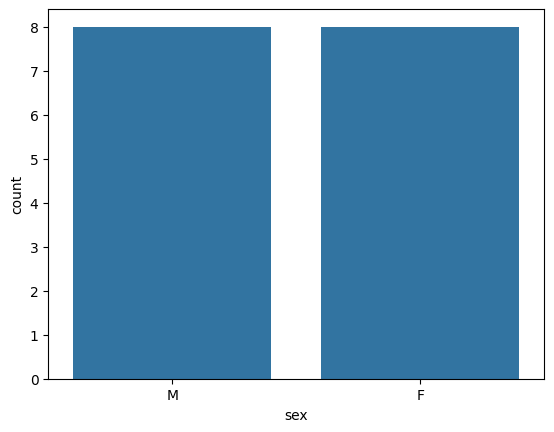

In [13]:
sns.countplot(participant_overview_df, x="sex")

Uniform distribution for gender

In [ ]:
participant_overview_df.sort_values(by="age", inplace=True)
participant_overview_df.head(100)

,sub,sex,age,height(cm),weight(kg),leg_length(cm),activity_level,dual_task_visit,dt_start_num1,dt_start_num2,st_lac_baseline1,st_lac_baseline2,st_lac_fatigue,st_time_to_fatigue(min),st_borg_scale,st_HR_baseline,st_HR_fatigue,dt_lac_baseline1,dt_lac_baseline2,dt_lac_fatigue,dt_time_to_fatigue(min),dt_borg_scale,dt_HR_baseline,dt_HR_fatigue
15,sub_18,F,21,165.0,54.0,78.0,1,1,8895,6267,0.7,0.8,5.6,7.0,16.5,63,185,NaN,NaN,3.5,20.5,17.0,65.0,195.0
0,sub_01,M,24,173.0,70.0,82.5,3,2,5308,7942,0.8,0.8,4.8,22.0,18.0,62,185,0.7,0.8,3.2,18.0,18.0,63.0,178.0
10,sub_12,M,24,179.5,65.0,82.5,2,1,8978,7270,0.6,0.6,8.8,6.0,18.0,92,194,0.8,0.7,10.2,7.0,18.0,70.0,196.0
12,sub_14,M,24,182.5,85.0,86.0,1,1,8603,3510,0.8,0.9,7.6,5.5,17.0,73,180,0.8,0.9,6.3,8.0,18.0,71.0,181.0
13,sub_15,F,24,172.0,54.0,85.5,2,2,5704,7494,1.2,1.1,5.5,9.5,18.0,84,193,1.1,0.8,4.1,6.5,17.0,87.0,192.0
14,sub_17,F,24,168.0,61.0,80.5,3,1,8065,3764,0.8,0.8,6.2,8.5,15.5,78,169,1.0,1.2,5.9,15.5,17.0,75.0,173.0
6,sub_08,F,26,168.5,70.0,82.0,3,2,7930,4675,0.6,0.6,7.0,6.5,18.5,91,182,0.6,0.5,4.2,7.0,18.0,83.0,180.0
8,sub_10,F,26,169.0,72.0,85.0,2,1,5540,6907,1.6,1.5,3.3,12.0,16.0,77,173,0.8,0.6,5.2,10.5,16.0,78.0,186.0
2,sub_03,M,27,190.0,103.0,93.5,3,2,6267,8818,1.5,1.5,2.8,11.0,17.5,73,157,1.0,1.1,2.5,9.0,18.0,NaN,NaN
7,sub_09,M,27,185.0,79.0,86.0,1,2,4203,7526,0.9,0.8,8.7,12.5,18.0,73,186,0.9,0.7,9.1,8.5,18.0,84.0,188.0


<Axes: xlabel='age'>

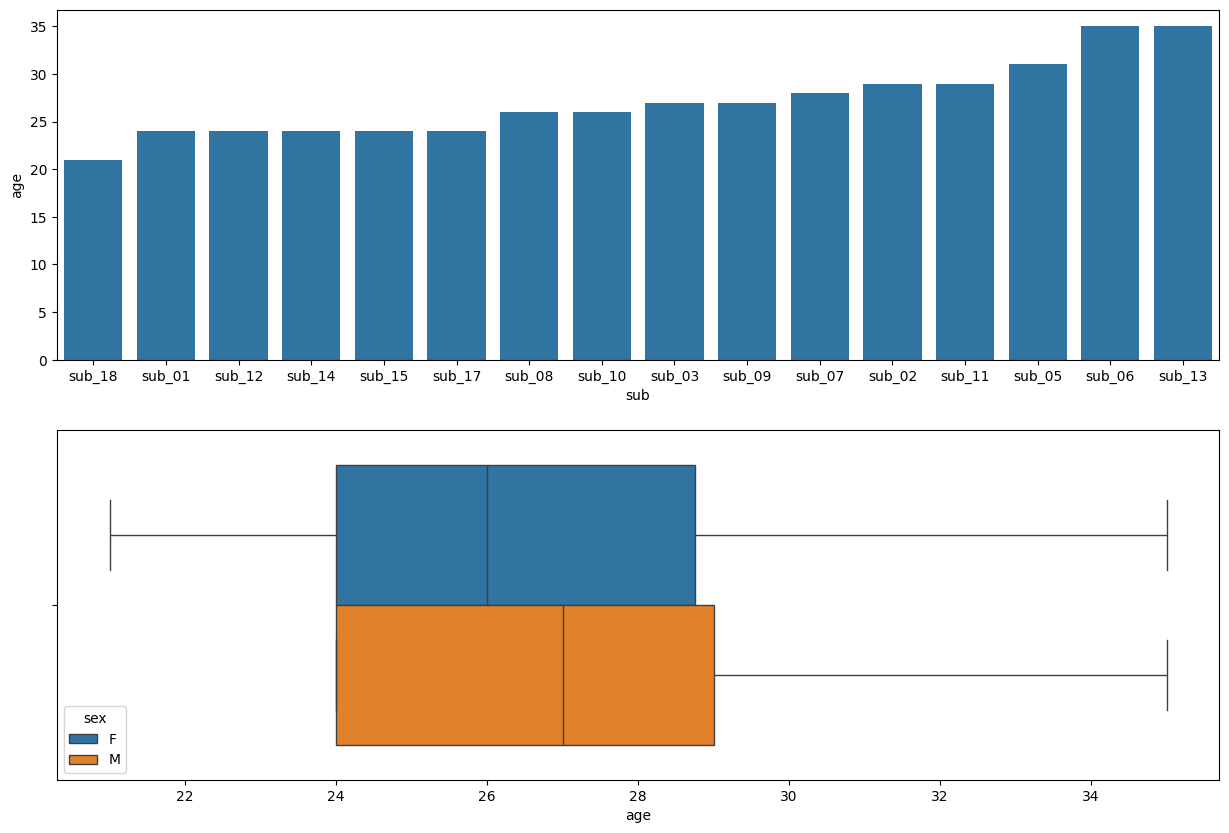

In [ ]:
fig, axes = plt.subplots(2,1,figsize=(15,10))

sns.barplot(participant_overview_df, x=id_column, y="age", ax=axes[0])
sns.boxplot(participant_overview_df, x="age", hue="sex", ax=axes[1])

Average is mid 20's. The last half of 20's (25-30) contains half of participants. Males tend to be a bit older than females.

<Axes: xlabel='weight(kg)'>

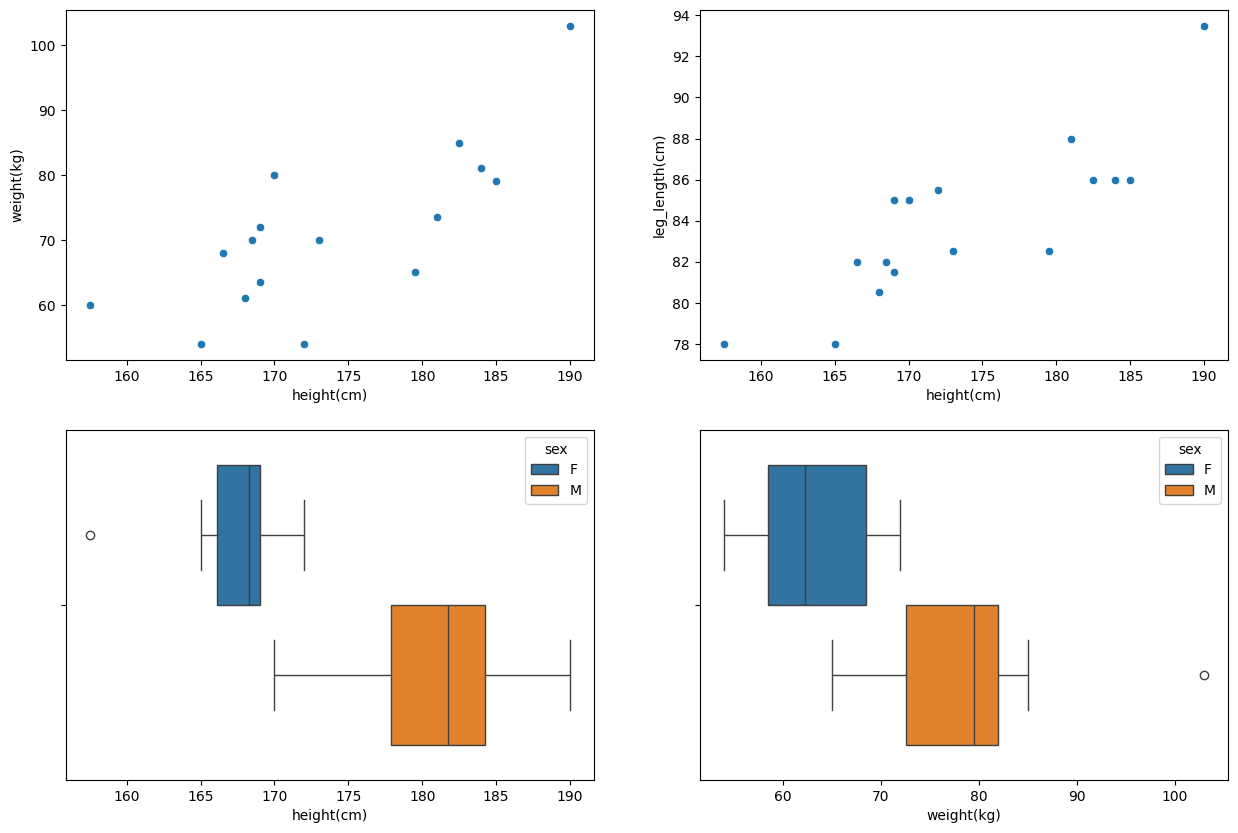

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(15,10))

sns.scatterplot(participant_overview_df,x="height(cm)",y="weight(kg)",ax=axes[0][0])
sns.scatterplot(participant_overview_df,x="height(cm)",y="leg_length(cm)",ax=axes[0][1])

sns.boxplot(participant_overview_df,x="height(cm)",hue="sex",ax=axes[1][0])
sns.boxplot(participant_overview_df,x="weight(kg)",hue="sex",ax=axes[1][1])

Increasing trend for weight, height and leg length. As expected, males tend to be have higher heights and weights compared to females. Does age and gender affect activity levels?

<Axes: xlabel='sex', ylabel='count'>

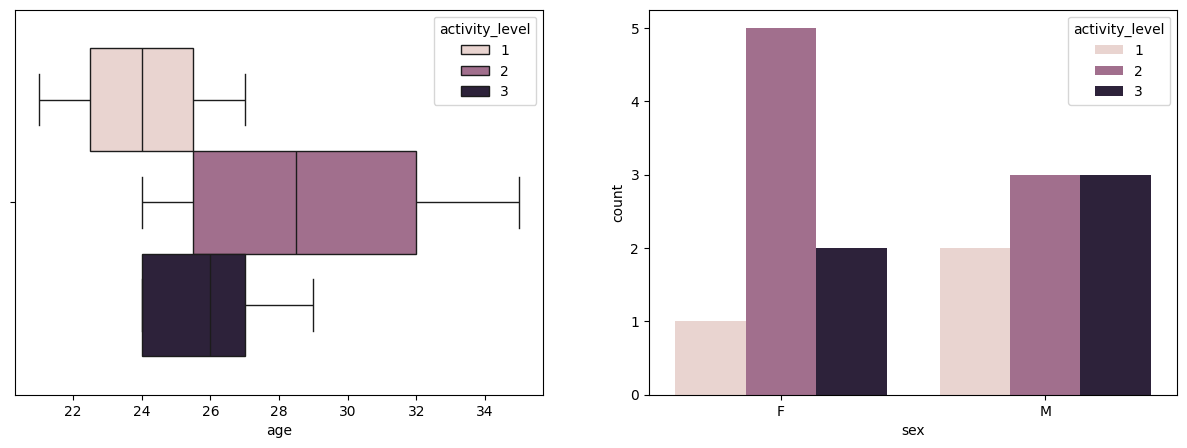

In [43]:
fig, axes = plt.subplots(1,2,figsize=(15,5))

sns.boxplot(participant_overview_df,x="age",hue="activity_level",ax=axes[0])
sns.countplot(participant_overview_df,x="sex",hue="activity_level",ax=axes[1])

The younger side has less activity levels but it's not strong. Females are mostly at activity level 2 but interestingly, males don't show this relationship.

<Axes: xlabel='st_borg_scale'>

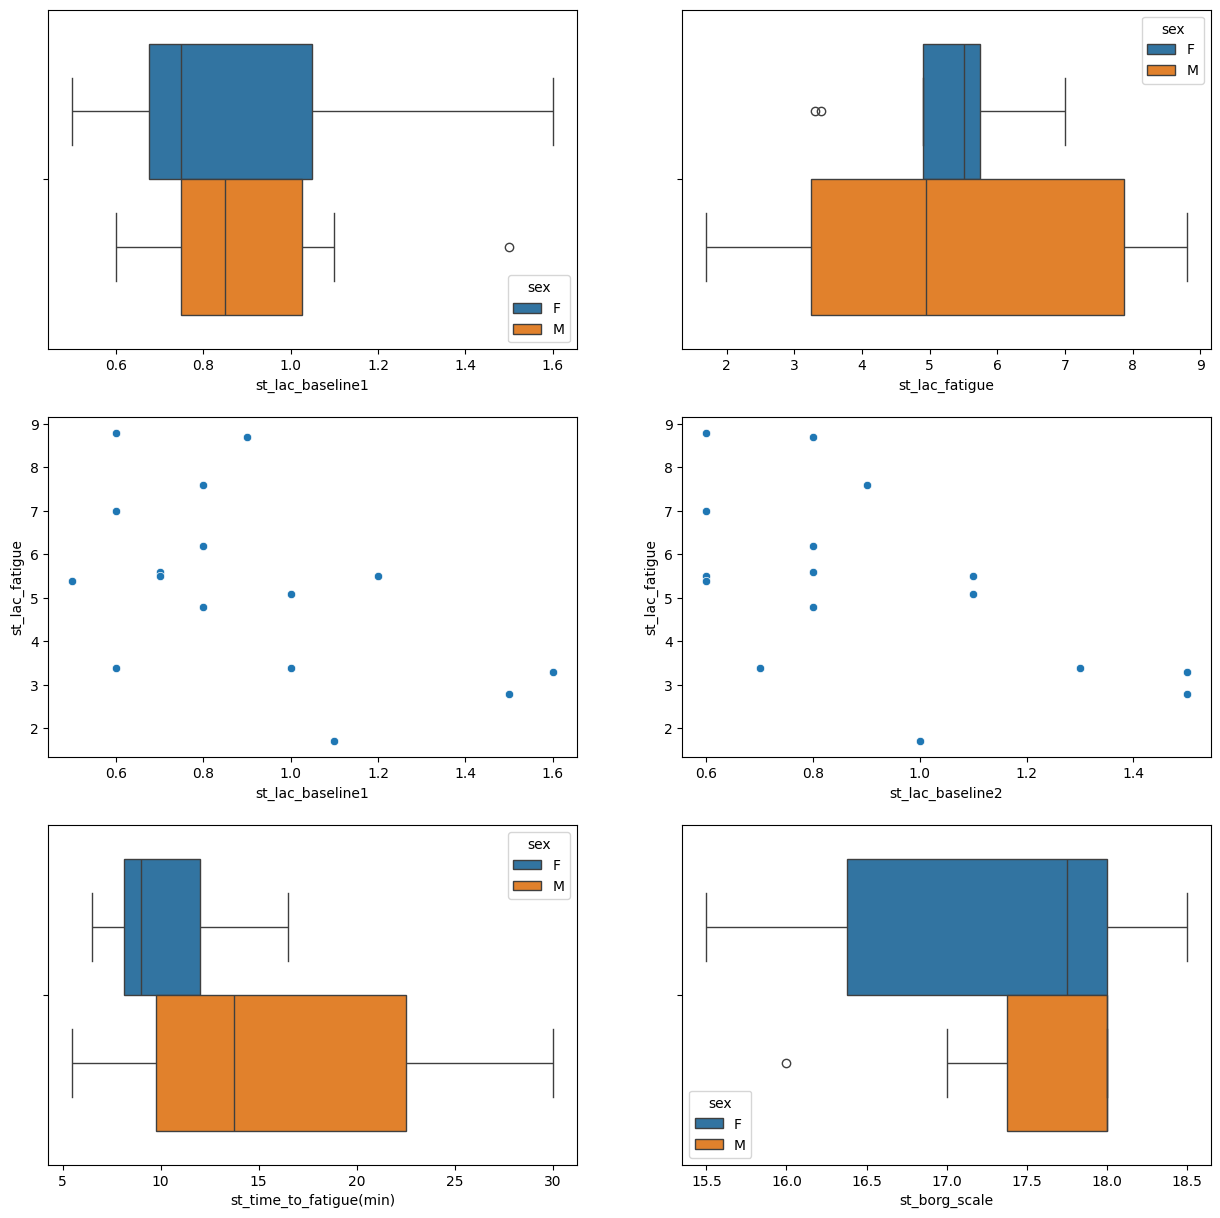

In [53]:
fig, axes = plt.subplots(3,2,figsize=(15,15))

sns.boxplot(participant_overview_df,x="st_lac_baseline1",hue="sex",ax=axes[0][0])
sns.boxplot(participant_overview_df,x="st_lac_fatigue",hue="sex",ax=axes[0][1])

sns.scatterplot(participant_overview_df,x="st_lac_baseline1",y="st_lac_fatigue",ax=axes[1][0])
sns.scatterplot(participant_overview_df,x="st_lac_baseline2",y="st_lac_fatigue",ax=axes[1][1])

sns.boxplot(participant_overview_df,x="st_time_to_fatigue(min)",hue="sex",ax=axes[2][0])
sns.boxplot(participant_overview_df,x="st_borg_scale",hue="sex",ax=axes[2][1])

Males on average have higher lactate levels compared to females. Females have much higher variance compared to males. Females also tend to feel more strain compared to males after the protocol. This is also proven by the time to fatigue. Post fatiguing protocol lactate levels are much higher but have a negative relationship with higher lactate levels which indicates people who are active tend to feel less fatigue during the protocol. Based on this evidence, it's interesting to see males report much higher RPE values compared to females even though their post fatigue protocol lactate levels are much lower. 

<Axes: xlabel='st_HR_fatigue', ylabel='age'>

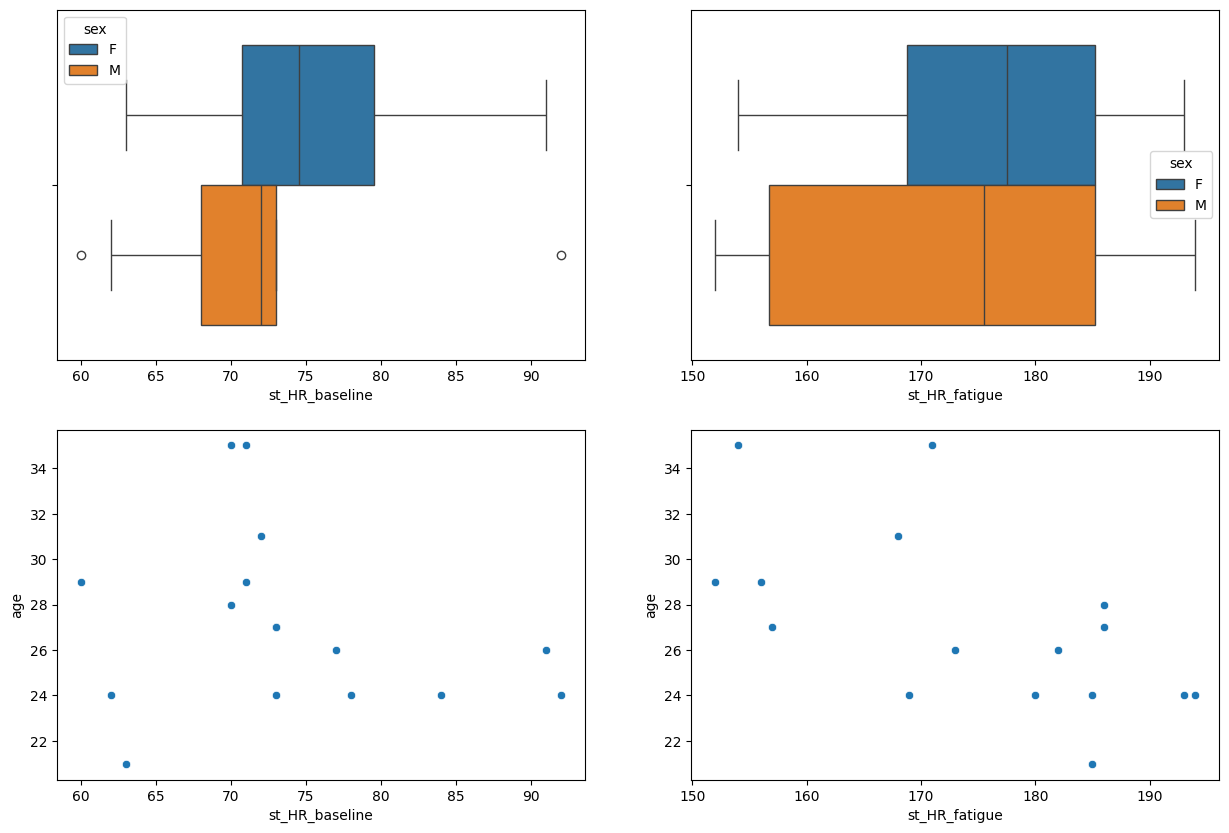

In [55]:
fig, axes = plt.subplots(2,2,figsize=(15,10))

sns.boxplot(participant_overview_df,x="st_HR_baseline",hue="sex",ax=axes[0][0])
sns.boxplot(participant_overview_df,x="st_HR_fatigue",hue="sex",ax=axes[0][1])

sns.scatterplot(participant_overview_df,x="st_HR_baseline",y="age",ax=axes[1][0])
sns.scatterplot(participant_overview_df,x="st_HR_fatigue",y="age",ax=axes[1][1])

Higher resting rate is linked to lower fitness. The fatiguing protocol works since heart rates are much higher with minimum being 150 bpm. Age tends to have a negative relationship with heart rate which makes sense. How does dual task visits compare to single task visits?

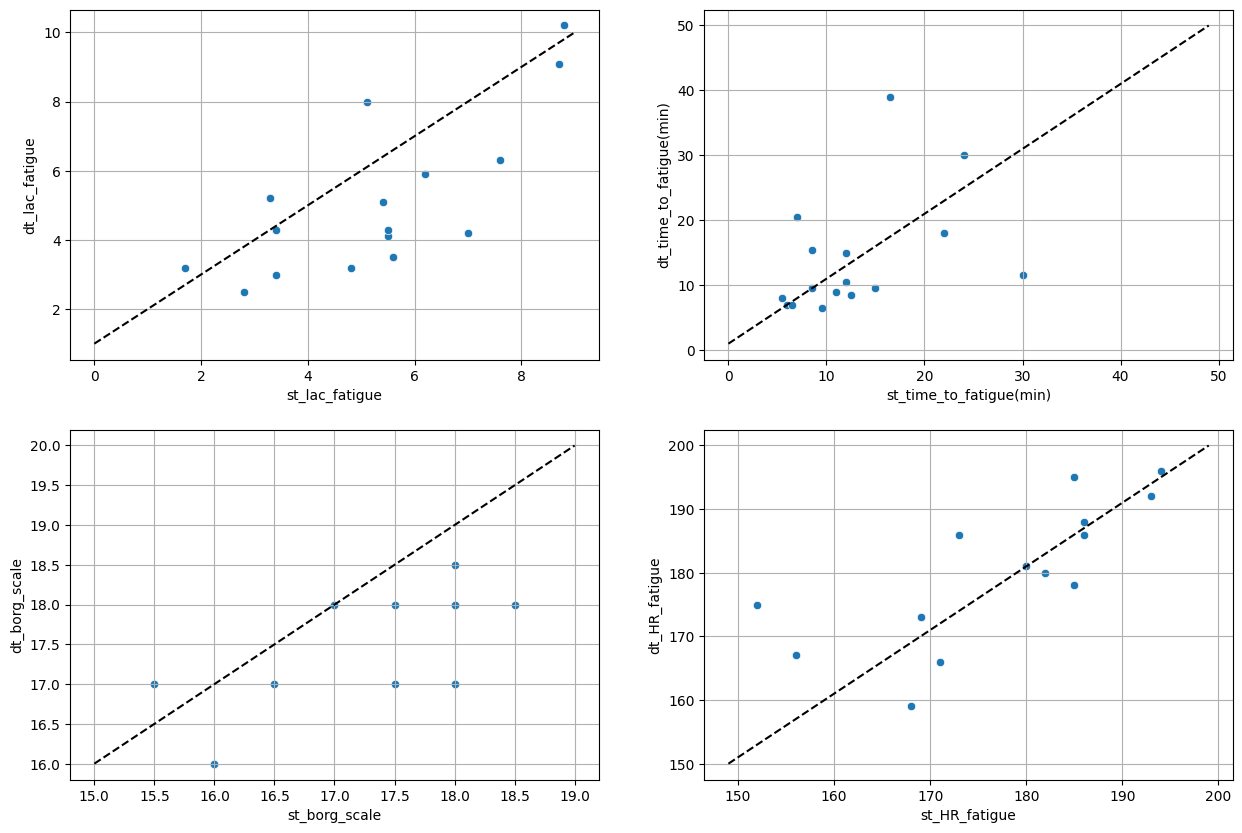

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(15,10))

x = np.linspace(1, 10, 10)
y = np.linspace(1, 50, 10)
b = np.linspace(16, 20, 10)
h = np.linspace(150, 200, 10)

sns.scatterplot(participant_overview_df,x="st_lac_fatigue",y="dt_lac_fatigue",ax=axes[0][0])
sns.scatterplot(participant_overview_df,x="st_time_to_fatigue(min)",y="dt_time_to_fatigue(min)",ax=axes[0][1])
sns.scatterplot(participant_overview_df,x="st_borg_scale",y="dt_borg_scale",ax=axes[1][0])
sns.scatterplot(participant_overview_df,x="st_HR_fatigue",y="dt_HR_fatigue",ax=axes[1][1])

axes[0][0].plot(x-1, x, color='black', linestyle='--')
axes[0][1].plot(y-1, y, color='black', linestyle='--')
axes[1][0].plot(b-1, b, color='black', linestyle='--')
axes[1][1].plot(h-1, h, color='black', linestyle='--')

axes[0][0].grid(True)
axes[0][1].grid(True)
axes[1][0].grid(True)
axes[1][1].grid(True)

Lactate levels seem much lower in comparison for dual task visits. However, due to lack of data, this can be safely ignored. 